In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
dataset = pd.read_csv("../assets/csv-files/churn-modelling.csv")
dataset.head(3)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1


In [3]:
# Drop columns with object (string) type data
dataset = dataset.select_dtypes(exclude=["object"])
dataset.head(3)

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,619,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,608,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,502,42,8,159660.80,3,1,0,113931.57,1


In [4]:
# Check for null values
dataset.isnull().sum() # No null values

RowNumber          0
CustomerId         0
CreditScore        0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [5]:
# Seperate input and output data
input_data = dataset.iloc[:, :-1]
output_data = dataset.iloc[:, -1]

In [6]:
# Scaling the input data
from sklearn.preprocessing import StandardScaler

In [7]:
ss = StandardScaler()
input_data = pd.DataFrame(ss.fit_transform(input_data), columns=input_data.columns)

In [8]:
# Train test split
from sklearn.model_selection import train_test_split

In [9]:
x_train, x_test, y_train, y_test = train_test_split(input_data, output_data, test_size=0.2, random_state=42)

In [10]:
# Create an artificial neural network
import tensorflow
from keras.layers import Dense, BatchNormalization
from keras.models import Sequential
from keras.callbacks import EarlyStopping
from keras.regularizers import L2

In [11]:
ann = Sequential() # Object initialization

In [12]:
# Build different layers
ann.add(Dense(8, input_dim=x_train.shape[1], activation="relu",  kernel_regularizer=L2(l2=0.01)))
ann.add(BatchNormalization()) 
ann.add(Dense(6, activation="relu", kernel_regularizer=L2(l2=0.01)))
ann.add(BatchNormalization()) 
ann.add(Dense(4, activation="relu", kernel_regularizer=L2(l2=0.01)))  
ann.add(BatchNormalization()) 
ann.add(Dense(2, activation="relu", kernel_regularizer=L2(l2=0.01)))  
ann.add(BatchNormalization()) 
ann.add(Dense(1, activation="sigmoid")) 

C:\Users\kusha\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
# Compile the model
ann.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

In [14]:
# Train the model
ann.fit(x_train, y_train, batch_size=100, epochs=50, validation_data=(x_test, y_test), callbacks=EarlyStopping())

Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.4703 - loss: 1.0106 - val_accuracy: 0.5430 - val_loss: 0.9089
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5522 - loss: 0.8796 - val_accuracy: 0.6770 - val_loss: 0.8313
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6156 - loss: 0.8062 - val_accuracy: 0.7435 - val_loss: 0.7473
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6900 - loss: 0.7372 - val_accuracy: 0.7575 - val_loss: 0.6837
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7097 - loss: 0.6916 - val_accuracy: 0.7710 - val_loss: 0.6385
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7390 - loss: 0.6389 - val_accuracy: 0.7885 - val_loss: 0.5953
Epoch 7/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7574 - loss: 0.5975 - val_accuracy: 0.8035 - val_loss: 0.5561
Epoch 8/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7668 - loss: 0.5704 - val_accuracy: 0.8035 - val

In [15]:
# Training and testing accuracy of each epoch
train_accuracy = ann.history.history["accuracy"]
test_accuracy = ann.history.history["val_accuracy"]
train_accuracy, test_accuracy

([0.48637500405311584,
  0.5674999952316284,
  0.6368749737739563,
  0.6945000290870667,
  0.7142500281333923,
  0.737625002861023,
  0.7591249942779541,
  0.7757499814033508,
  0.7897499799728394,
  0.7942500114440918,
  0.7976250052452087,
  0.8019999861717224,
  0.8091250061988831,
  0.8098750114440918,
  0.8146250247955322,
  0.8191249966621399,
  0.8223749995231628,
  0.8288750052452087,
  0.8263750076293945,
  0.8307499885559082,
  0.8326249718666077,
  0.8352500200271606,
  0.8399999737739563,
  0.8450000286102295,
  0.8503749966621399,
  0.8512499928474426,
  0.8497499823570251,
  0.8498749732971191,
  0.8514999747276306,
  0.8491250276565552],
 [0.5429999828338623,
  0.6769999861717224,
  0.7434999942779541,
  0.7574999928474426,
  0.7710000276565552,
  0.7885000109672546,
  0.8034999966621399,
  0.8034999966621399,
  0.8034999966621399,
  0.8195000290870667,
  0.8220000267028809,
  0.824999988079071,
  0.8270000219345093,
  0.8264999985694885,
  0.828499972820282,
  0.8259999

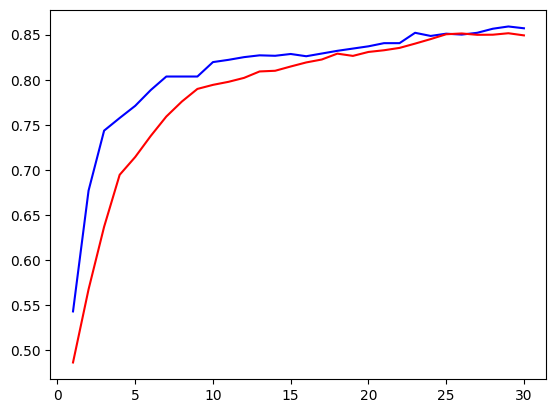

In [16]:
# Visualize the accuracy
plt.plot([i+1 for i in range(len(test_accuracy))], test_accuracy, color="blue")
plt.plot([i+1 for i in range(len(train_accuracy))], train_accuracy, color="red")
plt.show()

In [17]:
# Check the accuracy of our model
from sklearn.metrics import accuracy_score

In [18]:
# Predictions of x_train
predict_x_train = ann.predict(x_train)
x_train_predictions = []
for i in predict_x_train:
    if i[0] > 0.5:
        x_train_predictions.append(1)
    else:
        x_train_predictions.append(0)
# View predictions
x_train_predictions

250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


[0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,


In [19]:
# Predictions of x_test
predict_x_test = ann.predict(x_test)
x_test_predictions = []
for i in predict_x_test:
    if i[0] > 0.5:
        x_test_predictions.append(1)
    else:
        x_test_predictions.append(0)
# View predictions
x_test_predictions

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,


In [20]:
# Get accuracy
train_data_accuracy = accuracy_score(y_train, x_train_predictions) * 100 
test_data_accuracy = accuracy_score(y_test, x_test_predictions) * 100
train_data_accuracy, test_data_accuracy

(85.5, 85.7)

In [21]:
"""If the training accuracy is more than testing accuracy, the model is overfitted.
To avoid overfitting, we can use Dropout Layer to minimize the gaps between the accuracies."""

'If the training accuracy is more than testing accuracy, the model is overfitted.\nTo avoid overfitting, we can use Dropout Layer to minimize the gaps between the accuracies.'

#### Dropout Layer

In [22]:
from keras.layers import Dropout

In [23]:

# Build different layers
ann.add(BatchNormalization()) 
ann.add(Dense(8, input_dim=x_train.shape[1], activation="relu",  kernel_regularizer=L2(l2=0.01)))
ann.add(Dropout(0.3)) # Dropout layer with 30% to first layer
ann.add(BatchNormalization()) 
ann.add(Dense(6, activation="relu", kernel_regularizer=L2(l2=0.01)))
ann.add(Dropout(0.3)) # Dropout layer to second layer
ann.add(BatchNormalization()) 
ann.add(Dense(4, activation="relu", kernel_regularizer=L2(l2=0.01)))  
ann.add(Dropout(0.3)) # Dropout layer to third layer
ann.add(BatchNormalization()) 
ann.add(Dense(2, activation="relu", kernel_regularizer=L2(l2=0.01)))  
ann.add(Dropout(0.3)) # Dropout layer to fourth layer
ann.add(BatchNormalization()) 
ann.add(Dense(1, activation="sigmoid")) 


C:\Users\kusha\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [24]:
# Compile the model
ann.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

In [25]:
# Train the model
ann.fit(x_train, y_train, batch_size=100, epochs=50, validation_data=(x_test, y_test), callbacks=EarlyStopping())

Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 15s 23ms/step - accuracy: 0.4637 - loss: 0.9046 - val_accuracy: 0.8035 - val_loss: 0.7359
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5245 - loss: 0.7905 - val_accuracy: 0.8035 - val_loss: 0.6710
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5949 - loss: 0.7029 - val_accuracy: 0.8035 - val_loss: 0.6230
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7162 - loss: 0.6452 - val_accuracy: 0.8035 - val_loss: 0.5826
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.8069 - loss: 0.6015 - val_accuracy: 0.8035 - val_loss: 0.5618
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8182 - loss: 0.5590 - val_accuracy: 0.8035 - val_loss: 0.5362
Epoch 7/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8177 - loss: 0.5401 - val_accuracy: 0.8035 - val_loss: 0.5267
Epoch 8/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8144 - loss: 0.5205 - val_accuracy: 0.8035 - 

In [26]:
# Training and testing accuracy of each epoch
train_accuracy = ann.history.history["accuracy"]
test_accuracy = ann.history.history["val_accuracy"]
train_accuracy, test_accuracy

([0.48212501406669617,
  0.5419999957084656,
  0.6116250157356262,
  0.7618749737739563,
  0.8052499890327454,
  0.8146250247955322,
  0.8172500133514404,
  0.8131250143051147,
  0.8193749785423279,
  0.815625011920929,
  0.8174999952316284,
  0.8230000138282776,
  0.8198750019073486],
 [0.8034999966621399,
  0.8034999966621399,
  0.8034999966621399,
  0.8034999966621399,
  0.8034999966621399,
  0.8034999966621399,
  0.8034999966621399,
  0.8034999966621399,
  0.8034999966621399,
  0.8034999966621399,
  0.8034999966621399,
  0.8180000185966492,
  0.8034999966621399])

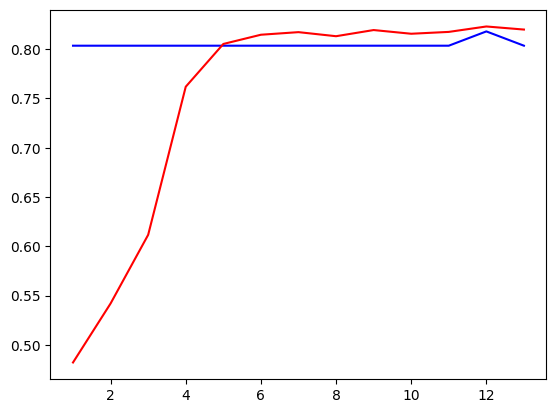

In [27]:
# Visualize the accuracy
plt.plot([i+1 for i in range(len(test_accuracy))], test_accuracy, color="blue")
plt.plot([i+1 for i in range(len(train_accuracy))], train_accuracy, color="red")
plt.show()